# Project Thesis — Simulation and Quadrature Implementation
**A Simulation-Based Decision Support Tool for the Risk-Averse International Newsvendor**

This notebook implements the computational framework described in Chapter 4 of the thesis. In addition to the Sample Average Approximation (SAA) engine, it includes an **exact Gauss–Hermite quadrature** solver for the independent case (Section 4.1.1), which serves as a noise-free reference benchmark against which the SAA results are validated.

---
### Note on a correction applied in this notebook
An earlier version of the notebook passed the *same* seed to the demand and exchange-rate RNGs in the independent branch (`seed_D = seed_X = SEEDMain`). Because `numpy.random.default_rng(seed)` is deterministic in its seed, this produced two uniform sequences that were *identical*, resulting in a sample correlation of ≈ 0.995 between $D$ and $X$ rather than 0. The "Zero correlation" rows in earlier experimental tables therefore reflected a near-comonotonic dependence structure, not true independence.

This has been corrected by drawing the two streams from distinct children of a single `SeedSequence`, so draws are reproducible **and** genuinely independent. The Gauss–Hermite quadrature implementation confirms the corrected SAA values. As a consequence, the CVaR figures in the "Zero" cells of the factorial tables change materially (e.g. H/H/Zero CVaR is ≈ 221, not 68.9); the **Negative** and **Positive** cells — generated by the Student-t copula, which uses a separate, correct seeding path — are unaffected.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from statistics import NormalDist
from scipy.stats import norm, lognorm, t, multivariate_t
from scipy.optimize import minimize_scalar, brentq
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Main seed for all random number generation
SEEDMain = 42

# 2. Classical Benchmark Model

In [2]:
# ----------------------------------------------------------
# Classical benchmark functions (domestic newsvendor, Section 2.1)
# ----------------------------------------------------------
def critical_fractile_classical(p, c, v):
    return (p - c) / (p - v)

def optimal_Q_classical_lognormal(mu_D, sigma_D, p, c, v):
    """
    Closed-form optimum for lognormal demand in the purely domestic newsvendor
    (deterministic cost). Used as a sanity check for the international case
    when sigma_X -> 0.
    """
    fractile = critical_fractile_classical(p, c, v)
    sigma_log_D = np.sqrt(np.log(1.0 + (sigma_D / mu_D)**2))
    mu_log_D = np.log(mu_D) - 0.5 * sigma_log_D**2
    scale = np.exp(mu_log_D)
    return lognorm.ppf(fractile, s=sigma_log_D, scale=scale)

# 3. International Risk-Neutral Benchmark
The risk-neutral optimum (Section 3.2) depends on the exchange rate only through $E[X]$:
$$Q^*_{\mathrm{RN}} = F_D^{-1}\!\left(\frac{p - c_f\,E[X]}{p - v}\right).$$
The analytical expected profit uses lognormal partial expectations (Appendix A, Listing A.1).

In [3]:
# ----------------------------------------------------------
# International risk-neutral benchmark (Section 3.2)
# ----------------------------------------------------------
def solve_analytical_rn(mu_D, sigma_D, p, c_f, mean_X, v):
    """
    Exact risk-neutral Q* for lognormal demand. Depends on sigma_X only
    through E[X], consistent with Eq. (3.6) and the discussion in Section 5.5.1.
    """
    c_eff = c_f * mean_X
    critical_fractile = (p - c_eff) / (p - v)
    critical_fractile = np.clip(critical_fractile, 1e-12, 1 - 1e-12)  # safety
    sigma_log_D = np.sqrt(np.log(1.0 + (sigma_D / mu_D)**2))
    mu_log_D = np.log(mu_D) - 0.5 * sigma_log_D**2
    return lognorm.ppf(critical_fractile, s=sigma_log_D, scale=np.exp(mu_log_D))

def analytical_expected_profit(Q, mu_D, sigma_D, mean_X, p, c_f, v):
    """
    Exact expected profit E[pi(Q)] for a lognormal D, using the partial
    expectation identity for lognormal variables (Appendix A, Listing A.1).
    Uses only E[X], because the cost component decouples from D
    (Section 3.2).
    """
    sigma_ln = np.sqrt(np.log(1 + (sigma_D / mu_D)**2))
    mu_ln = np.log(mu_D) - 0.5 * sigma_ln**2
    z1 = (np.log(Q) - mu_ln - sigma_ln**2) / sigma_ln
    z2 = (np.log(Q) - mu_ln) / sigma_ln
    E_min = np.exp(mu_ln + 0.5 * sigma_ln**2) * norm.cdf(z1) + Q * (1 - norm.cdf(z2))
    return (p - v) * E_min + (v - c_f * mean_X) * Q

# 4. Downside Risk Models: Mean-CVaR, Constrained CVaR, and VaR
The solvers below implement the scalar one-dimensional equivalents of the LP in Eq. (4.11) / (4.12) and the MILP in Eq. (4.9), as described in Section 4.3.4. All methods evaluate the exact SAA objective in Eq. (4.6) (via sorting) and are mathematically equivalent to the formal LP / MILP representations but are considerably more efficient for a scalar decision variable $Q$.

### 4.1 CVaR solvers (Mean-CVaR and Constrained CVaR)

In [4]:
def solve_cvar_family_models(d, x, w, p, c_f, v,
                             model_type="mean_cvar",
                             lam=0.0, max_cvar=None, alpha=0.95):
    """
    Unified one-dimensional solver for Scenario-RN, Mean-CVaR, and
    Constrained CVaR. Mathematically equivalent to the LPs in Eqs.
    (4.11)-(4.12), but evaluates the exact SAA objective (4.6) directly.
    
    Notes
    -----
    * CVaR(Q) is convex in Q (Section 4.3.3, following Gotoh & Takano 2007),
      with CVaR(0) = 0. The feasible set {Q : CVaR(Q) <= Omega_max} is
      therefore a connected interval [0, Q_upper], and the bisection below
      identifies its upper boundary Q_upper.
    """
    d = np.asarray(d); x = np.asarray(x); w = np.asarray(w)
    S = len(d)
    Q_hi = float(np.max(d) * 2.0)  # safe upper bound

    def metrics(Q):
        sales = np.minimum(Q, d)
        leftover = np.maximum(Q - d, 0.0)
        profits = p * sales + v * leftover - c_f * x * Q
        EP = float(np.sum(w * profits))
        losses = -profits
        
        # weighted empirical VaR
        idx = np.argsort(losses)
        ls = losses[idx]; ws = w[idx]
        cum = np.cumsum(ws)
        k = int(np.searchsorted(cum, alpha, side='left'))
        if k >= S:
            k = S - 1
        VaR = ls[k]
        CVaR = VaR + (1.0 / (1.0 - alpha)) * float(np.sum(w * np.maximum(losses - VaR, 0.0)))
        return EP, VaR, CVaR

    # ---- Scenario-RN: maximise SAA expected profit ----
    if model_type == "scenario_rn":
        res = minimize_scalar(lambda Q: -metrics(Q)[0],
                              bounds=(0, Q_hi), method='bounded',
                              options={'xatol': 1e-4})
        Q_star = float(res.x)
        return Q_star, metrics(Q_star)[0]

    # ---- Mean-CVaR: maximise  EP - lam * CVaR  (Eq. 4.10 / 4.11) ----
    if model_type == "mean_cvar":
        def obj(Q):
            EP, _, CVaR = metrics(Q)
            return -(EP - lam * CVaR)
        res = minimize_scalar(obj, bounds=(0, Q_hi), method='bounded',
                              options={'xatol': 1e-4})
        Q_star = float(res.x)
        return Q_star, metrics(Q_star)[0]

    # ---- Constrained CVaR: max EP s.t. CVaR <= max_cvar  (Eq. 4.12) ----
    if model_type == "constrained_cvar":
        # Unconstrained optimum first (the SAA risk-neutral Q)
        res_rn = minimize_scalar(lambda Q: -metrics(Q)[0],
                                 bounds=(0, Q_hi), method='bounded',
                                 options={'xatol': 1e-4})
        Q_rn = float(res_rn.x)
        EP_rn, _, CVaR_rn = metrics(Q_rn)
        
        if (max_cvar is None) or (CVaR_rn <= max_cvar):
            return Q_rn, EP_rn

        # CVaR(Q) is convex with CVaR(0) = 0, so the feasible region is an
        # interval [0, Q_upper]. Bisect on [0, Q_rn] to find Q_upper.
        lo, hi = 0.0, Q_rn
        for _ in range(60):
            mid = (lo + hi) / 2.0
            _, _, CVaR_mid = metrics(mid)
            if CVaR_mid <= max_cvar:
                lo = mid
            else:
                hi = mid
        Q_star = lo
        return Q_star, metrics(Q_star)[0]

    raise ValueError(f"Unknown model_type: {model_type}")

### 4.2 VaR solver (Constrained VaR)

In [5]:
def solve_constrained_var(d, x, w, p, c_f, v, max_var, alpha=0.95):
    """
    Scalar solver for the VaR chance constraint (Eq. 4.9 in the thesis).
    Equivalent to the MILP but solved by direct empirical-quantile
    evaluation (no binary variables, no Big-M). See Section 4.3.2.
    """
    d = np.asarray(d); x = np.asarray(x); w = np.asarray(w)
    Q_hi = float(np.max(d) * 2.0)

    def metrics(Q):
        sales = np.minimum(Q, d)
        leftover = np.maximum(Q - d, 0.0)
        profits = p * sales + v * leftover - c_f * x * Q
        EP = float(np.sum(w * profits))
        losses = -profits
        
        idx = np.argsort(losses)
        ls = losses[idx]; ws = w[idx]
        cum = np.cumsum(ws)
        k = int(np.searchsorted(cum, alpha, side='left'))
        if k >= len(ls):
            k = len(ls) - 1
        VaR = ls[k]
        return EP, VaR

    res_rn = minimize_scalar(lambda Q: -metrics(Q)[0],
                             bounds=(0, Q_hi), method='bounded',
                             options={'xatol': 1e-4})
    Q_rn = float(res_rn.x)
    EP_rn, VaR_rn = metrics(Q_rn)

    if VaR_rn <= max_var:
        return Q_rn, EP_rn

    lo, hi = 0.0, Q_rn
    for _ in range(60):
        mid = (lo + hi) / 2.0
        _, VaR_mid = metrics(mid)
        if VaR_mid <= max_var:
            lo = mid
        else:
            hi = mid
    Q_star = lo
    EP_star = metrics(Q_star)[0]
    return Q_star, EP_star

# 5. Scenario Engine for Richer Models
The engine generates Monte Carlo scenarios under three dependence specifications from Section 4.1:
1. **Independent baseline** (Section 4.1.1): lognormal marginals drawn from two independent streams.
2. **Bivariate lognormal / Gaussian copula** (Section 4.1.2): used only as the baseline in the copula stress test (Section 5.5).
3. **Student-t copula** (Section 4.1.3): the default dependence model used throughout.

**Seeding.** For the independent branch, two children of a single `SeedSequence` are spawned to produce *reproducible and genuinely independent* draws of $D$ and $X$. The previous implementation reused a single seed and produced two identical uniform sequences, resulting in near-comonotonic draws.m

In [6]:
# ----------------------------------------------------------
# Marginal distribution helpers (Lognormal)
# ----------------------------------------------------------
def demand_quantile_lognormal(u, mu_D, sigma_D):
    """Lognormal demand quantile with target mean mu_D and std sigma_D."""
    sigma_log_D = np.sqrt(np.log(1.0 + (sigma_D / mu_D)**2))
    mu_log_D = np.log(mu_D) - 0.5 * sigma_log_D**2
    scale = np.exp(mu_log_D)
    return lognorm.ppf(u, s=sigma_log_D, scale=scale)

def exchange_rate_quantile_lognormal(u, mean_X, sigma_X):
    """Lognormal exchange-rate quantile with target mean mean_X and std sigma_X."""
    sigma_log_X = np.sqrt(np.log(1.0 + (sigma_X / mean_X)**2))
    mu_log_X = np.log(mean_X) - 0.5 * sigma_log_X**2
    scale = np.exp(mu_log_X)
    return lognorm.ppf(u, s=sigma_log_X, scale=scale)

# ----------------------------------------------------------
# Independent marginal generators (Lognormal)
# ----------------------------------------------------------
def simulate_demand_lognormal(n_scenarios, mu_D, sigma_D, seed=None):
    """Simulate Lognormal demand matching target mean and std."""
    rng = np.random.default_rng(seed)
    sigma_log_D = np.sqrt(np.log(1.0 + (sigma_D / mu_D)**2))
    mu_log_D = np.log(mu_D) - 0.5 * sigma_log_D**2
    return rng.lognormal(mean=mu_log_D, sigma=sigma_log_D, size=n_scenarios)

def simulate_exchange_rate_lognormal(n_scenarios, mean_X, sigma_X, seed=None):
    """Simulate Lognormal exchange rates matching target mean and std."""
    rng = np.random.default_rng(seed)
    sigma_log_X = np.sqrt(np.log(1.0 + (sigma_X / mean_X)**2))
    mu_log_X = np.log(mean_X) - 0.5 * sigma_log_X**2
    return rng.lognormal(mean=mu_log_X, sigma=sigma_log_X, size=n_scenarios)

# ----------------------------------------------------------
# Scenario table construction
# ----------------------------------------------------------
def equal_probabilities(n_scenarios):
    if n_scenarios <= 0:
        raise ValueError("n_scenarios must be positive.")
    return np.full(n_scenarios, 1.0 / n_scenarios)

def build_scenario_table(demand_scenarios, exchange_rate_scenarios, probabilities=None):
    d = np.asarray(demand_scenarios, dtype=float)
    x = np.asarray(exchange_rate_scenarios, dtype=float)
    
    if len(d) != len(x):
        raise ValueError("Demand and exchange-rate arrays must have the same length.")
    
    n = len(d)
    if probabilities is None:
        w = equal_probabilities(n)
    else:
        w = np.asarray(probabilities, dtype=float)
        if len(w) != n:
            raise ValueError("Probability vector must match scenario length.")
        if np.any(w < 0):
            raise ValueError("Probabilities must be nonnegative.")
        if not np.isclose(w.sum(), 1.0):
            raise ValueError("Probabilities must sum to 1.")
            
    return pd.DataFrame({
        "Scenario": np.arange(1, n + 1),
        "Demand": d,
        "Exchange Rate": x,
        "Probability": w
    })

In [7]:
# ----------------------------------------------------------
# Independent scenario engine  (CORRECTED: spawns two distinct streams)
# ----------------------------------------------------------
def _spawn_two_streams(seed):
    """Return two independent, reproducible child RNGs from a base seed."""
    ss = np.random.SeedSequence(seed)
    s1, s2 = ss.spawn(2)
    return np.random.default_rng(s1), np.random.default_rng(s2)

def generate_independent_scenarios(n_scenarios, mu_D, sigma_D, mean_X, sigma_X, seed=None):
    """
    Independent Lognormal demand and exchange-rate scenarios. Uses
    SeedSequence.spawn(2) so the D and X draws are reproducible AND
    genuinely independent for any given base seed.
    """
    rng_D, rng_X = _spawn_two_streams(seed)
    
    sigma_log_D = np.sqrt(np.log(1.0 + (sigma_D / mu_D)**2))
    mu_log_D = np.log(mu_D) - 0.5 * sigma_log_D**2
    sigma_log_X = np.sqrt(np.log(1.0 + (sigma_X / mean_X)**2))
    mu_log_X = np.log(mean_X) - 0.5 * sigma_log_X**2
    
    demand_scenarios = rng_D.lognormal(mean=mu_log_D, sigma=sigma_log_D, size=n_scenarios)
    exchange_rate_scenarios = rng_X.lognormal(mean=mu_log_X, sigma=sigma_log_X, size=n_scenarios)
    probabilities = equal_probabilities(n_scenarios)
    
    scenario_table = build_scenario_table(
        demand_scenarios=demand_scenarios,
        exchange_rate_scenarios=exchange_rate_scenarios,
        probabilities=probabilities
    )
    
    return {
        "demand_scenarios": demand_scenarios,
        "exchange_rate_scenarios": exchange_rate_scenarios,
        "probabilities": probabilities,
        "scenario_table": scenario_table,
        "dependence_type": "independent"
    }

# ----------------------------------------------------------
# Gaussian copula (Bivariate Lognormal)  --  Section 4.1.2
# ----------------------------------------------------------
def simulate_bivariate_lognormal(n_scenarios, mu_D, sigma_D, mu_X, sigma_X, rho, seed=None):
    """Simulate (D, X) from a bivariate Lognormal distribution (Gaussian copula)."""
    if not (-1 < rho < 1):
        raise ValueError("rho must satisfy -1 < rho < 1.")
    if sigma_D <= 0 or sigma_X <= 0:
        raise ValueError("sigma_D and sigma_X must be positive.")
        
    rng = np.random.default_rng(seed)
    sigma_log_D = np.sqrt(np.log(1.0 + (sigma_D / mu_D)**2))
    mu_log_D = np.log(mu_D) - 0.5 * sigma_log_D**2
    sigma_log_X = np.sqrt(np.log(1.0 + (sigma_X / mu_X)**2))
    mu_log_X = np.log(mu_X) - 0.5 * sigma_log_X**2
    
    mean = np.array([mu_log_D, mu_log_X])
    cov = np.array([
        [sigma_log_D**2, rho * sigma_log_D * sigma_log_X],
        [rho * sigma_log_D * sigma_log_X, sigma_log_X**2]
    ])
    
    samples = rng.multivariate_normal(mean=mean, cov=cov, size=n_scenarios)
    return np.exp(samples[:, 0]), np.exp(samples[:, 1])

def generate_dependent_scenarios_joint_normal(
    n_scenarios, mu_D, sigma_D, mean_X, sigma_X, rho, seed=None):
    """
    Generate dependent scenarios from the joint lognormal (Gaussian-copula)
    model. Used only as the baseline in the copula stress test, Section 5.5.1.
    """
    demand_scenarios, exchange_rate_scenarios = simulate_bivariate_lognormal(
        n_scenarios=n_scenarios, mu_D=mu_D, sigma_D=sigma_D,
        mu_X=mean_X, sigma_X=sigma_X, rho=rho, seed=seed
    )
    probabilities = equal_probabilities(n_scenarios)
    scenario_table = build_scenario_table(
        demand_scenarios=demand_scenarios,
        exchange_rate_scenarios=exchange_rate_scenarios,
        probabilities=probabilities
    )
    
    return {
        "demand_scenarios": demand_scenarios,
        "exchange_rate_scenarios": exchange_rate_scenarios,
        "probabilities": probabilities,
        "scenario_table": scenario_table,
        "dependence_type": "joint_normal",
        "rho": rho
    }

# ----------------------------------------------------------
# Student-t copula  --  Section 4.1.3
# ----------------------------------------------------------
def simulate_t_copula_uniforms(n_scenarios, rho, nu=4.0, seed=None):
    """
    Draw dependent uniforms from a Student-t copula.
    Lower nu = heavier joint tails.
    """
    cov = np.array([[1.0, rho], [rho, 1.0]])
    rvs = multivariate_t.rvs(loc=[0.0, 0.0], shape=cov, df=nu,
                             size=n_scenarios, random_state=seed)
    u1 = t.cdf(rvs[:, 0], df=nu)
    u2 = t.cdf(rvs[:, 1], df=nu)
    return u1, u2

def generate_dependent_scenarios_t_copula(
    n_scenarios, mu_D, sigma_D, mean_X, sigma_X, rho, nu=4.0, seed=None):
    """Generate dependent scenarios using a Student-t copula with lognormal marginals."""
    u_D, u_X = simulate_t_copula_uniforms(
        n_scenarios=n_scenarios, rho=rho, nu=nu, seed=seed
    )
    demand_scenarios = demand_quantile_lognormal(u=u_D, mu_D=mu_D, sigma_D=sigma_D)
    exchange_rate_scenarios = exchange_rate_quantile_lognormal(u=u_X, mean_X=mean_X, sigma_X=sigma_X)
    
    probabilities = equal_probabilities(n_scenarios)
    scenario_table = build_scenario_table(
        demand_scenarios=demand_scenarios,
        exchange_rate_scenarios=exchange_rate_scenarios,
        probabilities=probabilities
    )
    
    return {
        "demand_scenarios": demand_scenarios,
        "exchange_rate_scenarios": exchange_rate_scenarios,
        "probabilities": probabilities,
        "scenario_table": scenario_table,
        "dependence_type": "t_copula",
        "rho": rho,
        "nu": nu
    }

In [8]:
# ----------------------------------------------------------
# Unified wrapper
# ----------------------------------------------------------
def generate_scenarios(
    n_scenarios, mu_D, sigma_D, mean_X, sigma_X,
    dependence="independent", rho=None, nu=4.0,
    seed=None):
    """
    Unified interface for scenario generation.
    A single `seed` argument is used across all branches; the independent
    branch spawns two child streams internally.
    """
    if dependence == "independent":
        return generate_independent_scenarios(
            n_scenarios=n_scenarios,
            mu_D=mu_D, sigma_D=sigma_D,
            mean_X=mean_X, sigma_X=sigma_X,
            seed=seed
        )
    elif dependence == "joint_normal":
        if rho is None:
            raise ValueError("rho must be provided when dependence='joint_normal'.")
        return generate_dependent_scenarios_joint_normal(
            n_scenarios=n_scenarios, mu_D=mu_D, sigma_D=sigma_D,
            mean_X=mean_X, sigma_X=sigma_X,
            rho=rho, seed=seed
        )
    elif dependence == "t_copula":
        if rho is None:
            raise ValueError("rho must be provided when dependence='t_copula'.")
        return generate_dependent_scenarios_t_copula(
            n_scenarios=n_scenarios, mu_D=mu_D, sigma_D=sigma_D,
            mean_X=mean_X, sigma_X=sigma_X,
            rho=rho, nu=nu, seed=seed
        )
    else:
        raise ValueError("dependence must be 'independent', 'joint_normal', or 't_copula'.")

# ----------------------------------------------------------
# Helpers for downstream use
# ----------------------------------------------------------
def extract_scenario_arrays(scenario_table):
    return {
        "demand_scenarios": scenario_table["Demand"].to_numpy(),
        "exchange_rate_scenarios": scenario_table["Exchange Rate"].to_numpy(),
        "probabilities": scenario_table["Probability"].to_numpy()
    }

def scenario_summary(scenario_table):
    return pd.DataFrame({
        "Metric": [
            "Number of scenarios", "Mean demand", "Std. demand",
            "Mean exchange rate", "Std. exchange rate",
            "Sample correlation", "Probability sum"
        ],
        "Value": [
            len(scenario_table),
            scenario_table["Demand"].mean(),
            scenario_table["Demand"].std(ddof=0),
            scenario_table["Exchange Rate"].mean(),
            scenario_table["Exchange Rate"].std(ddof=0),
            scenario_table["Demand"].corr(scenario_table["Exchange Rate"]),
            scenario_table["Probability"].sum()
        ]
    })

# 6. Computational Setup and Convergence (Thesis §5.2)
Reproduces Table 5.1 and Figure 5.1 of the thesis: standard deviation of the SAA optimum $Q^*$ across 10 independent random seeds, at the High/High/Negative stress scenario.

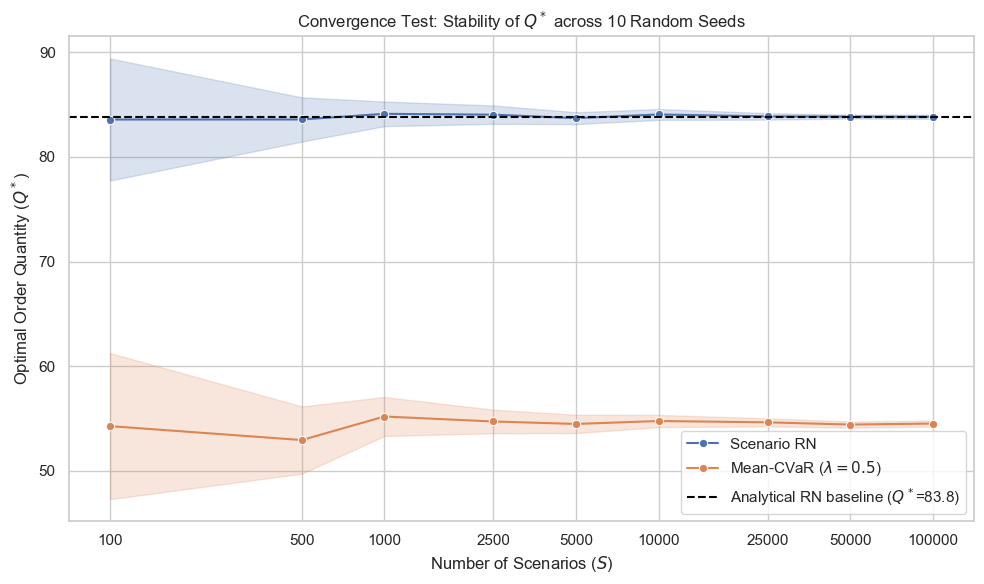

Standard deviation of Q* across seeds:


Model,Mean-CVaR ($\lambda=0.5$),Scenario RN
N,,
100,6.98,5.83
500,3.22,2.11
1000,1.86,1.18
2500,1.13,0.88
5000,0.88,0.57
10000,0.58,0.52
25000,0.39,0.31
50000,0.29,0.18
100000,0.29,0.19


In [9]:
def run_convergence_test():
    # Baseline parameters (thesis §5.1) — High/High/Negative regime
    p = 14.0
    c_f = 10.0
    mean_X = 1.0
    v = 3.0
    mu_D = 100.0
    sigma_D = 35.0           # High demand volatility
    sigma_X = 0.20           # High FX volatility
    rho = -0.6               # Negative dependence
    nu = 4.0                 # Student-t copula degrees of freedom

    # Analytical Risk-Neutral benchmark (depends only on E[X], so valid here)
    q_analytical = solve_analytical_rn(mu_D, sigma_D, p, c_f, mean_X, v)

    # Convergence loop
    n_values = [100, 500, 1000, 2500, 5000, 10000, 25000, 50000, 100000]
    seeds = list(range(1, 11))
    results = []

    for n in n_values:
        for seed in seeds:
            scen_data = generate_scenarios(
                n_scenarios=n,
                mu_D=mu_D, sigma_D=sigma_D,
                mean_X=mean_X, sigma_X=sigma_X,
                dependence="t_copula",
                rho=rho, nu=nu,
                seed=seed,
            )
            d = scen_data["demand_scenarios"]
            x = scen_data["exchange_rate_scenarios"]
            w = scen_data["probabilities"]

            q_rn, _   = solve_cvar_family_models(d, x, w, p, c_f, v,
                                                 model_type="scenario_rn")
            q_cvar, _ = solve_cvar_family_models(d, x, w, p, c_f, v,
                                                 model_type="mean_cvar", lam=0.5)

            results.append({"N": n, "Seed": seed,
                            "Model": "Scenario RN", "Q*": q_rn})
            results.append({"N": n, "Seed": seed,
                            "Model": r"Mean-CVaR ($\lambda=0.5$)", "Q*": q_cvar})

    df_conv = pd.DataFrame(results)

    # Plot
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    sns.lineplot(data=df_conv, x="N", y="Q*", hue="Model",
                 marker="o", errorbar="sd", err_style="band")

    plt.axhline(q_analytical, color="black", linestyle="--",
                label=f"Analytical RN baseline ($Q^*$={q_analytical:.1f})")

    plt.xscale("log")
    plt.xticks(n_values, labels=[str(n) for n in n_values])
    plt.title("Convergence Test: Stability of $Q^*$ across 10 Random Seeds")
    plt.xlabel("Number of Scenarios ($S$)")
    plt.ylabel("Optimal Order Quantity ($Q^*$)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    std_df = df_conv.groupby(["N", "Model"])["Q*"].std().unstack()
    print("Standard deviation of Q* across seeds:")
    display(std_df.round(2))


run_convergence_test()

# 7. Experimental Results and Sensitivity Analysis (Thesis Chapter 5)

## Experiment I — Thesis §5.3: Impact of Volatility and Dependence
Full 2×2×3 factorial with demand volatility $\sigma_D \in \{15, 35\}$, FX volatility $\sigma_X \in \{0.05, 0.20\}$, and dependence $\rho \in \{-0.6, 0.0, +0.6\}$.
- $\rho = \pm 0.6$ cells: Student-t copula with $\nu = 4$ (Section 4.1.3).
- $\rho = 0$ cell: **independent baseline** (Section 4.1.1).

In [10]:
# Common baseline parameters (thesis Section 5.1)
N_SCENARIOS = 50000
p = 14.0
c_f = 10.0
mean_X = 1.0
v = 3.0
mu_D = 100.0
alpha_level = 0.95
lam_penalty = 0.5
max_cvar_limit = 200.0   # Omega_max
max_var_limit = 150.0    # V_max

# Factorial design levels
sigma_D_levels = [15.0, 35.0]   # Low / High demand volatility
sigma_X_levels = [0.05, 0.20]   # Low / High FX volatility
correlations = [
    ("Negative", "t_copula", -0.6),
    ("Zero",     "independent", 0.0),
    ("Positive", "t_copula", +0.6),
]

def calculate_cvar_for_Q(Q, d, x, w, p, c_f, v, alpha=0.95):
    """Utility: empirical CVaR at a specific order quantity (used for reporting)."""
    sales = np.minimum(Q, d)
    leftover = np.maximum(Q - d, 0.0)
    profits = p * sales + v * leftover - c_f * x * Q
    losses = -profits
    
    idx = np.argsort(losses)
    ls = losses[idx]; ws = w[idx]
    cum = np.cumsum(ws)
    k = int(np.searchsorted(cum, alpha, side='left'))
    if k >= len(ls):
        k = len(ls) - 1
    eta = ls[k]
    return eta + np.mean(np.maximum(losses - eta, 0.0)) / (1.0 - alpha)

In [11]:
# --- Execute the 2x2x3 factorial ---
results = []
start_time = time.time()

for sig_D in sigma_D_levels:
    for sig_X in sigma_X_levels:
        for corr_name, dep_type, rho in correlations:
            
            # 1. Generate SAA scenarios (used for all four SAA-based policies)
            scen_data = generate_scenarios(
                n_scenarios=N_SCENARIOS,
                mu_D=mu_D, sigma_D=sig_D,
                mean_X=mean_X, sigma_X=sig_X,
                dependence=dep_type,
                rho=(rho if dep_type != "independent" else None),
                nu=4.0,
                seed=SEEDMain
            )
            d = scen_data["demand_scenarios"]
            x = scen_data["exchange_rate_scenarios"]
            w = scen_data["probabilities"]
            
            # 2. Risk-Neutral (ANALYTICAL for Q and EP; SAA for CVaR exposure)
            q_rn  = solve_analytical_rn(mu_D, sig_D, p, c_f, mean_X, v)
            ep_rn = analytical_expected_profit(q_rn, mu_D, sig_D, mean_X, p, c_f, v)
            cvar_rn = calculate_cvar_for_Q(q_rn, d, x, w, p, c_f, v, alpha_level)
                
            # 3. Mean-CVaR (Solved and evaluated via SAA)
            q_mcvar, ep_mcvar = solve_cvar_family_models(
                d, x, w, p, c_f, v,
                model_type="mean_cvar", lam=lam_penalty, alpha=alpha_level
            )
            cvar_mcvar = calculate_cvar_for_Q(q_mcvar, d, x, w, p, c_f, v, alpha_level)
                
            # 4. Constrained CVaR (Solved and evaluated via SAA)
            q_ccvar, ep_ccvar = solve_cvar_family_models(
                d, x, w, p, c_f, v,
                model_type="constrained_cvar",
                max_cvar=max_cvar_limit, alpha=alpha_level
            )
            cvar_ccvar = calculate_cvar_for_Q(q_ccvar, d, x, w, p, c_f, v, alpha_level)
                
            # 5. Constrained VaR (Solved and evaluated via SAA)
            q_var, ep_var = solve_constrained_var(
                d, x, w, p, c_f, v,
                max_var=max_var_limit, alpha=alpha_level
            )
            cvar_var = calculate_cvar_for_Q(q_var, d, x, w, p, c_f, v, alpha_level)
            
            base = {
                "Demand Volatility": "High" if sig_D == 35.0 else "Low",
                "FX Volatility":     "High" if sig_X == 0.20 else "Low",
                "Correlation":       corr_name
            }
            
            for mod_name, q_opt, ep, cv in [
                ("Risk-Neutral",     q_rn,    ep_rn,    cvar_rn),
                ("Mean-CVaR",        q_mcvar, ep_mcvar, cvar_mcvar),
                ("Constrained CVaR", q_ccvar, ep_ccvar, cvar_ccvar),
                ("Constrained VaR",  q_var,   ep_var,   cvar_var),
            ]:
                row = base.copy()
                row.update({
                    "Model":           mod_name,
                    "Optimal Q*":      round(q_opt, 2),
                    "Expected Profit": round(ep, 2),
                    "CVaR (95%)":      round(cv, 2)
                })
                results.append(row)

df_results = pd.DataFrame(results)
print(f"Experiment I completed in {time.time() - start_time:.2f} seconds.\n")
display(df_results)

Experiment I completed in 3.17 seconds.



,Demand Volatility,FX Volatility,Correlation,Model,Optimal Q*,Expected Profit,CVaR (95%)
0,Low,Low,Negative,Risk-Neutral,93.88,340.20,-70.56
1,Low,Low,Negative,Mean-CVaR,79.97,315.33,-177.23
2,Low,Low,Negative,Constrained CVaR,93.84,339.84,-70.90
3,Low,Low,Negative,Constrained VaR,93.84,339.84,-70.90
4,Low,Low,Zero,Risk-Neutral,93.88,340.20,-125.32
5,Low,Low,Zero,Mean-CVaR,83.63,325.91,-194.80
6,Low,Low,Zero,Constrained CVaR,93.82,339.90,-125.78
7,Low,Low,Zero,Constrained VaR,93.82,339.90,-125.78
8,Low,Low,Positive,Risk-Neutral,93.88,340.20,-181.03
9,Low,Low,Positive,Mean-CVaR,87.19,334.01,-217.13


## Efficient Frontier — Thesis §5.3.4
$\Omega_{\max}$-sweep in the H/H/Negative stress scenario (Student-t copula, $\rho = -0.6$, $\nu = 4$).

In [12]:
N_SCENARIOS = 50_000
p = 14.0
c_f = 10.0
v = 3.0
mean_X = 1.0
mu_D = 100.0
sig_D = 35.0
sig_X = 0.20
rho = -0.6
alpha_level = 0.95

scen_data_frontier = generate_scenarios(
    n_scenarios=N_SCENARIOS,
    mu_D=mu_D, sigma_D=sig_D,
    mean_X=mean_X, sigma_X=sig_X,
    dependence="t_copula", rho=rho, nu=4.0,
    seed=SEEDMain
)
d_f = scen_data_frontier["demand_scenarios"]
x_f = scen_data_frontier["exchange_rate_scenarios"]
w_f = scen_data_frontier["probabilities"]

cvar_limits = [50, 100, 150, 200, 250, 300, 350]
frontier_results = []

for limit in cvar_limits:
    q_opt, ep_opt = solve_cvar_family_models(
        d_f, x_f, w_f, p, c_f, v,
        model_type="constrained_cvar", max_cvar=limit, alpha=alpha_level
    )
    actual_cvar = calculate_cvar_for_Q(q_opt, d_f, x_f, w_f, p, c_f, v, alpha_level)
    
    frontier_results.append({
        "CVaR Limit":        limit,
        "Optimal Q*":        round(q_opt, 2),
        "Expected Profit":   round(ep_opt, 2),
        "Actual CVaR (95%)": round(actual_cvar, 2)
    })

# Unconstrained benchmark (analytical)
q_rn  = solve_analytical_rn(mu_D, sig_D, p, c_f, mean_X, v)
ep_rn = analytical_expected_profit(q_rn, mu_D, sig_D, mean_X, p, c_f, v)
cvar_rn = calculate_cvar_for_Q(q_rn, d_f, x_f, w_f, p, c_f, v, alpha_level)

frontier_results.append({
    "CVaR Limit":        "Unconstrained",
    "Optimal Q*":        round(q_rn, 2),
    "Expected Profit":   round(ep_rn, 2),
    "Actual CVaR (95%)": round(cvar_rn, 2)
})

df_frontier = pd.DataFrame(frontier_results)
print("Efficient frontier (H/H/Negative, t-copula nu=4):")
display(df_frontier)

Efficient frontier (H/H/Negative, t-copula nu=4):


,CVaR Limit,Optimal Q*,Expected Profit,Actual CVaR (95%)
0,50,45.53,180.79,50.00
1,100,55.37,216.32,100.00
2,150,61.36,234.95,150.00
3,200,66.38,248.02,200.00
4,250,71.07,257.67,250.00
5,300,75.62,264.29,300.00
6,350,80.11,268.05,350.00
7,Unconstrained,83.83,270.06,391.78


## Experiment II — Thesis §5.4: Macro-Economic Regime Analysis
Boom and Recession regimes with $\rho = \pm 0.6$ under the Student-t copula ($\nu = 4$). Neither regime is independent, so we rely purely on the SAA engine.

In [13]:
N_SCENARIOS = 50_000
p = 14.0
c_f = 10.0
v = 3.0
alpha_level = 0.95
lam_penalty = 0.5
max_cvar_limit = 200.0
max_var_limit = 150.0

regimes = {
    "Boom": {
        "mu_D": 120.0, "sigma_D": 15.0,
        "mean_X": 0.90, "sigma_X": 0.05,
        "rho": 0.6, "dependence": "t_copula"
    },
    "Recession": {
        "mu_D": 80.0, "sigma_D": 35.0,
        "mean_X": 1.20, "sigma_X": 0.20,
        "rho": -0.6, "dependence": "t_copula"
    },
}

results = []
start_time = time.time()

for regime_name, params in regimes.items():
    print(f"Simulating {regime_name} regime...")
    
    scen_data = generate_scenarios(
        n_scenarios=N_SCENARIOS,
        mu_D=params["mu_D"], sigma_D=params["sigma_D"],
        mean_X=params["mean_X"], sigma_X=params["sigma_X"],
        dependence=params["dependence"], rho=params["rho"], nu=4.0,
        seed=SEEDMain
    )
    d = scen_data["demand_scenarios"]
    x = scen_data["exchange_rate_scenarios"]
    w = scen_data["probabilities"]
    
    # Risk-neutral benchmark (analytical expected profit, SAA for CVaR)
    q_rn  = solve_analytical_rn(params["mu_D"], params["sigma_D"], p, c_f, params["mean_X"], v)
    ep_rn = analytical_expected_profit(q_rn, params["mu_D"], params["sigma_D"],
                                       params["mean_X"], p, c_f, v)
    cvar_rn = calculate_cvar_for_Q(q_rn, d, x, w, p, c_f, v, alpha_level)
    
    # Mean-CVaR
    q_mcvar, ep_mcvar = solve_cvar_family_models(d, x, w, p, c_f, v,
                              model_type="mean_cvar", lam=lam_penalty, alpha=alpha_level)
    cvar_mcvar = calculate_cvar_for_Q(q_mcvar, d, x, w, p, c_f, v, alpha_level)
    
    # Constrained CVaR
    q_ccvar, ep_ccvar = solve_cvar_family_models(d, x, w, p, c_f, v,
                              model_type="constrained_cvar", max_cvar=max_cvar_limit,
                              alpha=alpha_level)
    cvar_ccvar = calculate_cvar_for_Q(q_ccvar, d, x, w, p, c_f, v, alpha_level)
    
    # Constrained VaR
    q_var, ep_var = solve_constrained_var(d, x, w, p, c_f, v,
                                           max_var=max_var_limit, alpha=alpha_level)
    cvar_var = calculate_cvar_for_Q(q_var, d, x, w, p, c_f, v, alpha_level)
    
    for mod_name, q_opt, ep, cv in [
        ("Risk-Neutral",     q_rn,    ep_rn,    cvar_rn),
        ("Mean-CVaR",        q_mcvar, ep_mcvar, cvar_mcvar),
        ("Constrained CVaR", q_ccvar, ep_ccvar, cvar_ccvar),
        ("Constrained VaR",  q_var,   ep_var,   cvar_var),
    ]:
        results.append({
            "Regime":          regime_name,
            "Model":           mod_name,
            "Optimal Q*":      round(q_opt, 2),
            "Expected Profit": round(ep, 2),
            "CVaR (95%)":      round(cv, 2)
        })

df_regimes = pd.DataFrame(results)
print(f"\nExperiment II completed in {time.time() - start_time:.2f} seconds.\n")
display(df_regimes)

Simulating Boom regime...
Simulating Recession regime...

Experiment II completed in 0.70 seconds.



,Regime,Model,Optimal Q*,Expected Profit,CVaR (95%)
0,Boom,Risk-Neutral,117.39,535.48,-351.23
1,Boom,Mean-CVaR,111.15,529.84,-381.27
2,Boom,Constrained CVaR,117.32,535.48,-351.65
3,Boom,Constrained VaR,117.32,535.48,-351.65
4,Recession,Risk-Neutral,50.11,81.19,289.65
5,Recession,Mean-CVaR,26.00,51.52,73.90
6,Recession,Constrained CVaR,42.83,77.27,200.00
7,Recession,Constrained VaR,47.87,80.28,261.20


## Experiment III — Thesis §5.5: Tail Dependence and Copula Choice
Copula stress test: fix $(\sigma_D, \sigma_X, \rho)$ and vary the dependence family (Gaussian copula / t-copula with $\nu \in \{3, 4, 8\}$). Uses $S = 10^{6}$ scenarios per cell so the second-order differences are not obscured by sampling noise (Eq. 5.3 in the thesis).

In [14]:
N_SCENARIOS = 1000000
p = 14.0
c_f = 10.0
v = 3.0
mean_X = 1.0
mu_D = 100.0
sig_D = 35.0
sig_X = 0.20
rho = -0.6
alpha_level = 0.95

copulas_to_test = [
    ("Gaussian (Normal)", "joint_normal", None),
    ("Student-t (nu=8)",  "t_copula",     8.0),
    ("Student-t (nu=4)",  "t_copula",     4.0),
    ("Student-t (nu=3)",  "t_copula",     3.0),
]

fixed_cvar_limit = 200.0
copula_results = []

# Analytical risk-neutral Q* (identical across copulas since only E[X] matters)
q_rn_c  = solve_analytical_rn(mu_D, sig_D, p, c_f, mean_X, v)
ep_rn_c = analytical_expected_profit(q_rn_c, mu_D, sig_D, mean_X, p, c_f, v)

start_time = time.time()

for copula_name, copula_type, nu_val in copulas_to_test:
    scen_data_cop = generate_scenarios(
        n_scenarios=N_SCENARIOS,
        mu_D=mu_D, sigma_D=sig_D,
        mean_X=mean_X, sigma_X=sig_X,
        dependence=copula_type,
        rho=rho,
        nu=(nu_val if nu_val is not None else 4.0),
        seed=SEEDMain
    )
    d_c = scen_data_cop["demand_scenarios"]
    x_c = scen_data_cop["exchange_rate_scenarios"]
    w_c = scen_data_cop["probabilities"]
    
    cvar_rn_c = calculate_cvar_for_Q(q_rn_c, d_c, x_c, w_c, p, c_f, v, alpha_level)
    
    q_cc_c, ep_cc_c = solve_cvar_family_models(
        d_c, x_c, w_c, p, c_f, v,
        model_type="constrained_cvar",
        max_cvar=fixed_cvar_limit, alpha=alpha_level
    )
    cvar_cc_c = calculate_cvar_for_Q(q_cc_c, d_c, x_c, w_c, p, c_f, v, alpha_level)
    
    copula_results.append({
        "Copula Assumption": copula_name,
        "nu":                ("inf" if nu_val is None else nu_val),
        "Model":             "Risk-Neutral",
        "Optimal Q*":        round(q_rn_c, 2),
        "Expected Profit":   round(ep_rn_c, 2),
        "CVaR Exposure":     round(cvar_rn_c, 2)
    })
    
    copula_results.append({
        "Copula Assumption": copula_name,
        "nu":                ("inf" if nu_val is None else nu_val),
        "Model":             f"Constrained CVaR (Max={fixed_cvar_limit:g})",
        "Optimal Q*":        round(q_cc_c, 2),
        "Expected Profit":   round(ep_cc_c, 2),
        "CVaR Exposure":     round(cvar_cc_c, 2)
    })

df_copula = pd.DataFrame(copula_results)
df_copula["sort_key"] = df_copula["nu"].replace({"inf": 999}).astype(float)
df_copula = df_copula.sort_values(["sort_key", "Model"],
                                  ascending=[False, True]).drop(columns="sort_key")

print(f"Experiment III completed in {time.time() - start_time:.2f} seconds.\n")
display(df_copula)

Experiment III completed in 85.00 seconds.



C:\Users\cleme\AppData\Local\Temp\ipykernel_9784\3128619264.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copula["sort_key"] = df_copula["nu"].replace({"inf": 999}).astype(float)


,Copula Assumption,nu,Model,Optimal Q*,Expected Profit,CVaR Exposure
1,Gaussian (Normal),inf,Constrained CVaR (Max=200),67.70,251.75,200.00
0,Gaussian (Normal),inf,Risk-Neutral,83.83,270.06,376.22
3,Student-t (nu=8),8.0,Constrained CVaR (Max=200),66.93,249.90,200.00
2,Student-t (nu=8),8.0,Risk-Neutral,83.83,270.06,385.43
5,Student-t (nu=4),4.0,Constrained CVaR (Max=200),66.32,248.53,200.00
4,Student-t (nu=4),4.0,Risk-Neutral,83.83,270.06,392.81
7,Student-t (nu=3),3.0,Constrained CVaR (Max=200),66.01,247.82,200.00
6,Student-t (nu=3),3.0,Risk-Neutral,83.83,270.06,396.52


## Experiment IV — Thesis §5.6: Margin and Cost Structure Sensitivity
High-margin vs low-margin sectors at $p = 100$. The common stochastic environment uses $\rho = 0$ under the Student-t copula ($\nu = 4$).

> **Caveat.** A Student-t copula with $\rho = 0$ is *not* independent — it retains radial tail dependence through its shared chi-square mixing variable. We report results under this specification to match the thesis text.

In [15]:
N_SCENARIOS = 50000
mu_D = 100.0
sig_D = 35.0
mean_X = 1.0
sig_X = 0.10
alpha_level = 0.95
rho = 0.0

# Adjusted limits for the p = 100 scale
max_cvar_limit_HM = 1430.0
max_var_limit_HM  = 1070.0
lam_penalty = 0.5

sectors = {
    "High-Margin (Luxury/Pharma)": {"p": 100.0, "c_f": 35.0, "v": 10.0},
    "Low-Margin (Grocery/FMCG)":   {"p": 100.0, "c_f": 75.0, "v": 25.0},
}

# Common set of t-copula scenarios (rho = 0, nu = 4) so both sectors face
# identical uncertainty realizations
scen_data = generate_scenarios(
    n_scenarios=N_SCENARIOS,
    mu_D=mu_D, sigma_D=sig_D,
    mean_X=mean_X, sigma_X=sig_X,
    dependence="t_copula", rho=rho, nu=4.0,
    seed=SEEDMain
)
d = scen_data["demand_scenarios"]
x = scen_data["exchange_rate_scenarios"]
w = scen_data["probabilities"]

results = []
start_time = time.time()

for sector_name, params in sectors.items():
    p_val  = params["p"]
    cf_val = params["c_f"]
    v_val  = params["v"]
    
    # Analytical RN
    q_rn  = solve_analytical_rn(mu_D, sig_D, p_val, cf_val, mean_X, v_val)
    ep_rn = analytical_expected_profit(q_rn, mu_D, sig_D, mean_X, p_val, cf_val, v_val)
    cvar_rn = calculate_cvar_for_Q(q_rn, d, x, w, p_val, cf_val, v_val, alpha_level)
    
    # Mean-CVaR
    q_mcvar, ep_mcvar = solve_cvar_family_models(
        d, x, w, p_val, cf_val, v_val,
        model_type="mean_cvar", lam=lam_penalty, alpha=alpha_level
    )
    cvar_mcvar = calculate_cvar_for_Q(q_mcvar, d, x, w, p_val, cf_val, v_val, alpha_level)
    
    # Constrained CVaR
    q_ccvar, ep_ccvar = solve_cvar_family_models(
        d, x, w, p_val, cf_val, v_val,
        model_type="constrained_cvar",
        max_cvar=max_cvar_limit_HM, alpha=alpha_level
    )
    cvar_ccvar = calculate_cvar_for_Q(q_ccvar, d, x, w, p_val, cf_val, v_val, alpha_level)
    
    # Constrained VaR
    q_var, ep_var = solve_constrained_var(
        d, x, w, p_val, cf_val, v_val,
        max_var=max_var_limit_HM, alpha=alpha_level
    )
    cvar_var = calculate_cvar_for_Q(q_var, d, x, w, p_val, cf_val, v_val, alpha_level)
    
    for mod_name, q_opt, ep, cv in [
        ("Risk-Neutral",     q_rn,    ep_rn,    cvar_rn),
        ("Mean-CVaR",        q_mcvar, ep_mcvar, cvar_mcvar),
        ("Constrained CVaR", q_ccvar, ep_ccvar, cvar_ccvar),
        ("Constrained VaR",  q_var,   ep_var,   cvar_var),
    ]:
        results.append({
            "Sector":           sector_name,
            "Model":            mod_name,
            "Optimal Q*":       round(q_opt, 2),
            "Expected Profit":  round(ep, 2),
            "CVaR (95%)":       round(cv, 2)
        })

df_margin = pd.DataFrame(results)
print(f"Experiment IV completed in {time.time() - start_time:.2f} seconds.\n")
display(df_margin)

Experiment IV completed in 0.31 seconds.



,Sector,Model,Optimal Q*,Expected Profit,CVaR (95%)
0,High-Margin (Luxury/Pharma),Risk-Neutral,115.33,5386.68,-1222.31
1,High-Margin (Luxury/Pharma),Mean-CVaR,100.35,5301.55,-1630.40
2,High-Margin (Luxury/Pharma),Constrained CVaR,115.54,5399.01,-1216.38
3,High-Margin (Luxury/Pharma),Constrained VaR,115.54,5399.01,-1216.38
4,Low-Margin (Grocery/FMCG),Risk-Neutral,81.53,1653.39,911.95
5,Low-Margin (Grocery/FMCG),Mean-CVaR,61.90,1477.84,-78.15
6,Low-Margin (Grocery/FMCG),Constrained CVaR,81.78,1659.03,926.50
7,Low-Margin (Grocery/FMCG),Constrained VaR,81.78,1659.03,926.50
